In [1]:
import pandas as pd
from emotion_app import predict_emotion

def process_csv_for_emotion(csv_file_path, text_column_name, ground_truth_column_name=None):
    df = pd.read_csv(csv_file_path)

    df[text_column_name] = df[text_column_name].astype(str)

    results = df[text_column_name].apply(lambda text: predict_emotion(text))
    df['predicted_emotion'] = [r[0] for r in results]
    df['confidence'] = [r[1] for r in results]

    return df

csv = 'Emotion_classify_Data.csv'
text_column = 'Comment'
ground_truth_column = 'Emotion'

processed_df = process_csv_for_emotion(csv, text_column, ground_truth_column)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Calculate classification report
report = classification_report(processed_df[ground_truth_column], processed_df['predicted_emotion'])
print("Classification Report:\n", report)

# Calculate overall accuracy score
accuracy = accuracy_score(processed_df[ground_truth_column], processed_df['predicted_emotion'])
print(f"\nOverall Accuracy: {accuracy:.4f}")

Classification Report:
               precision    recall  f1-score   support

       anger       0.97      0.93      0.95      2000
     disgust       0.00      0.00      0.00         0
        fear       0.96      0.91      0.94      1937
         joy       0.99      0.93      0.96      2000
     neutral       0.00      0.00      0.00         0
     sadness       0.00      0.00      0.00         0
    surprise       0.00      0.00      0.00         0

    accuracy                           0.92      5937
   macro avg       0.42      0.40      0.41      5937
weighted avg       0.97      0.92      0.95      5937


Overall Accuracy: 0.9240


/Users/_a.h.x_/anaconda3/envs/pyspark311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/_a.h.x_/anaconda3/envs/pyspark311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/_a.h.x_/anaconda3/envs/pyspark311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

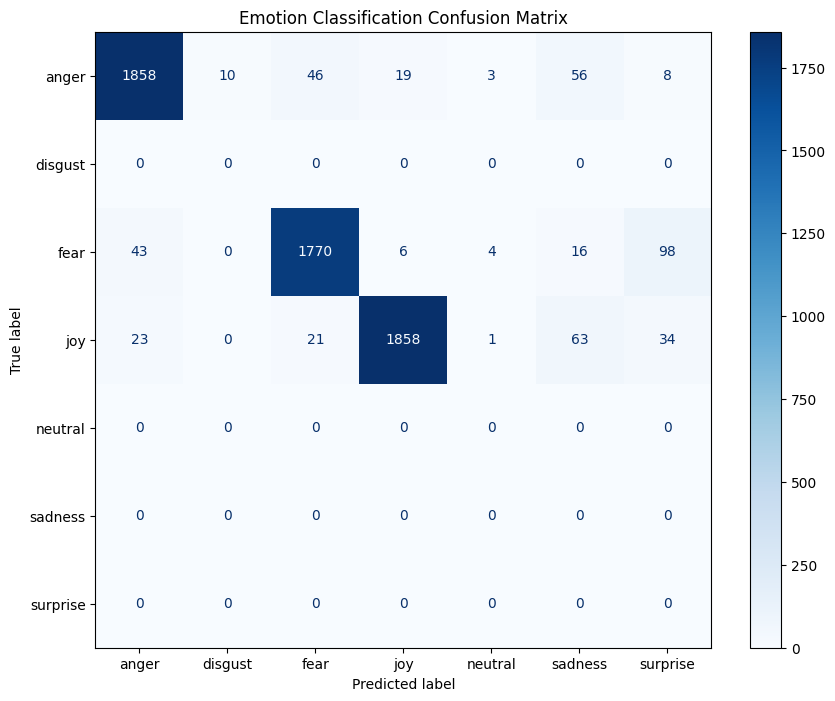

In [5]:
import matplotlib.pyplot as plt

def calculate_and_display_confusion_matrix(df, ground_truth_col, predicted_col):
    unique_labels = sorted(list(set(df[ground_truth_col].unique()).union(set(df[predicted_col].unique()))))
    cm = confusion_matrix(df[ground_truth_col], df[predicted_col], labels=unique_labels)
    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_labels)
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    ax.set_title('Emotion Classification Confusion Matrix')
    plt.show()

calculate_and_display_confusion_matrix(processed_df, ground_truth_column, 'predicted_emotion')